# Frequency and Severity GLMs

This notebook starts the actuarial modeling stage for the CASdatasets `freMTPL2` portfolio. A Poisson GLM models policy claim counts with exposure, and a Gamma GLM with a log link models positive claim amounts conditional on a claim. The [data audit](01_data_overview.ipynb), [frequency EDA](02_frequency_exploration.ipynb), and [severity EDA](03_severity_exploration.ipynb) provide the basis for this first specification.

Policies are split into training and held-out sets **before** either model is fitted. Every severity row follows its policy into the same set. This notebook fits and examines the models on training data; held-out performance and calibration belong to the later validation stage. All modeled relationships are conditional associations, not causal effects.

## 1. Load data and split by policy

The fixed random seed makes the 80/20 split reproducible. The same policy cannot appear in both sets, including when it has multiple severity records. `IDpol` is read as text to preserve the source representation. No observations are removed for the p99 diagnostic shown in the severity EDA.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from patsy import bs

frequency = pd.read_csv(
    Path("../data/raw/freMTPL2freq.csv"), dtype={"IDpol": "string"}
)
severity = pd.read_csv(
    Path("../data/raw/freMTPL2sev.csv"), dtype={"IDpol": "string"}
)

assert frequency["IDpol"].is_unique
assert frequency["Exposure"].gt(0).all()
assert severity["ClaimAmount"].gt(0).all()

rng = np.random.default_rng(2026)
train_mask = rng.random(len(frequency)) < 0.8
train_frequency = frequency.loc[train_mask].copy()
test_frequency = frequency.loc[~train_mask].copy()

assert set(train_frequency["IDpol"]).isdisjoint(set(test_frequency["IDpol"]))
display(pd.DataFrame({
    "policies": [len(train_frequency), len(test_frequency)],
    "exposure_years": [train_frequency["Exposure"].sum(),
                       test_frequency["Exposure"].sum()],
    "reported_claims": [train_frequency["ClaimNb"].sum(),
                        test_frequency["ClaimNb"].sum()],
}, index=["Training", "Held out"]).round(2))

,policies,exposure_years,reported_claims
Training,542830,287103.67,21079
Held out,135161,71379.17,5365


In [2]:
train_claims = severity.merge(
    train_frequency.drop(columns=["ClaimNb", "Exposure"]),
    on="IDpol", how="inner", validate="many_to_one"
)
test_claims = severity.loc[
    severity["IDpol"].isin(test_frequency["IDpol"])
].copy()

assert len(train_claims) + len(test_claims) == len(severity)
assert len(train_claims) == train_frequency["ClaimNb"].sum()
assert len(test_claims) == test_frequency["ClaimNb"].sum()
print("Training claim amounts:", len(train_claims))
print("Held-out claim amounts (reserved):", len(test_claims))

Training claim amounts: 21079
Held-out claim amounts (reserved): 5365


## 2. First model specification

For policy \(i\), the frequency model uses `log(E[ClaimNb_i]) = log(Exposure_i) + predictor_i`. The exposure term is an **offset**, so predictions can be expressed as claims per year of exposure. For an observed claim, the severity model uses `log(E[ClaimAmount | claim, X]) = predictor` with a Gamma mean-variance relationship. The models estimate separate conditional means; they are not combined into pure premium here.

Driver age and BonusMalus use cubic spline terms to allow bends without turning EDA bins into category cutoffs. BonusMalus has explicit interior spline knots at 75 and 100: its large pileup at 50 makes automatically chosen quantile knots degenerate. Vehicle age uses `log1p(VehAge)` to moderate its long range; density uses `log(Density)`. Vehicle power enters linearly in this first specification. Fuel type and region enter as categories. Area is omitted because it substantially overlaps with Density, and brand is deferred from this compact initial model. These choices can be revised after diagnostics and validation.

In [3]:
predictor_formula = (
    "bs(DrivAge, df=5, degree=3, lower_bound=18, upper_bound=100)"
    " + bs(BonusMalus, knots=(75, 100), degree=3, lower_bound=50, upper_bound=230)"
    " + np.log1p(VehAge) + VehPower + C(VehGas)"
    " + np.log(Density) + C(Region)"
)
print(predictor_formula)

bs(DrivAge, df=5, degree=3, lower_bound=18, upper_bound=100) + bs(BonusMalus, knots=(75, 100), degree=3, lower_bound=50, upper_bound=230) + np.log1p(VehAge) + VehPower + C(VehGas) + np.log(Density) + C(Region)


## 3. Fit the exposure-adjusted Poisson frequency model

`Exposure` is passed directly to statsmodels, which adds its logarithm to the linear predictor with coefficient fixed at one. The response remains the observed **count** `ClaimNb`, rather than a per-policy rate.

In [4]:
frequency_model = sm.GLM.from_formula(
    "ClaimNb ~ " + predictor_formula,
    data=train_frequency,
    family=sm.families.Poisson(),
    exposure=train_frequency["Exposure"],
)
frequency_fit = frequency_model.fit(maxiter=100)
print("Converged:", frequency_fit.converged)
print("Training policies:", int(frequency_fit.nobs))
print("Parameters:", len(frequency_fit.params))
print("Pearson chi-square / residual df:",
      round(frequency_fit.pearson_chi2 / frequency_fit.df_resid, 3))
print("Deviance / residual df:",
      round(frequency_fit.deviance / frequency_fit.df_resid, 3))

Converged: True
Training policies: 542830
Parameters: 36
Pearson chi-square / residual df: 1.869
Deviance / residual df: 0.241


## 4. Fit the claim-level Gamma severity model

Each training claim contributes one positive `ClaimAmount`. Several claims may share a policy ID and its characteristics. The Gamma log-link model is a first mean-severity model; the fixed settlement amounts and large-claim influence identified in EDA remain important limitations when interpreting it.

In [5]:
severity_model = sm.GLM.from_formula(
    "ClaimAmount ~ " + predictor_formula,
    data=train_claims,
    family=sm.families.Gamma(link=sm.families.links.Log()),
)
severity_fit = severity_model.fit(maxiter=100)
print("Converged:", severity_fit.converged)
print("Training claims:", int(severity_fit.nobs))
print("Parameters:", len(severity_fit.params))
print("Pearson chi-square / residual df:",
      round(severity_fit.pearson_chi2 / severity_fit.df_resid, 3))
print("Deviance / residual df:",
      round(severity_fit.deviance / severity_fit.df_resid, 3))

Converged: True
Training claims: 21079
Parameters: 36
Pearson chi-square / residual df: 18.06
Deviance / residual df: 1.513


## 5. Initial adjusted comparisons

Exponentiating a coefficient gives a multiplicative comparison **conditional on the other model terms**. The table limits itself to terms with straightforward interpretations. For `log(Density)`, the displayed comparison is for a doubling of density. Spline-basis coefficients are not individually interpreted; the profile plots below show their combined shape.

In [6]:
simple_terms = {
    "C(VehGas)[T.Regular]": ("Regular vs Diesel", 1.0),
    "VehPower": ("One-unit increase in VehPower", 1.0),
    "np.log(Density)": ("Doubling of Density", np.log(2)),
}

rows = []
for model_name, fit in [("Frequency", frequency_fit),
                        ("Severity", severity_fit)]:
    for term, (comparison, multiplier) in simple_terms.items():
        rows.append({
            "model": model_name,
            "comparison": comparison,
            "conditional_ratio": np.exp(fit.params[term] * multiplier),
        })
display(pd.DataFrame(rows).set_index(["model", "comparison"]).round(3))

conditional_ratio
model     comparison                                      
Frequency Regular vs Diesel                          0.835
          One-unit increase in VehPower              1.026
          Doubling of Density                        1.054
Severity  Regular vs Diesel                          1.003
          One-unit increase in VehPower              1.040
          Doubling of Density                        1.005

The next plots hold the other listed characteristics at one illustrative reference profile: vehicle age 6, vehicle power 6, Diesel fuel, median training density, and the most common training region. The age plot holds BonusMalus at 70; the BonusMalus plot holds driver age at 45. Frequency predictions use **one exposure-year**. These are adjusted model predictions for that profile, not population-average effects, causal effects, or held-out validation.

Reference profile: {'DrivAge': 45, 'BonusMalus': 70, 'VehAge': 6, 'VehPower': 6, 'VehGas': 'Diesel', 'Density': 393.0, 'Region': 'Centre'}


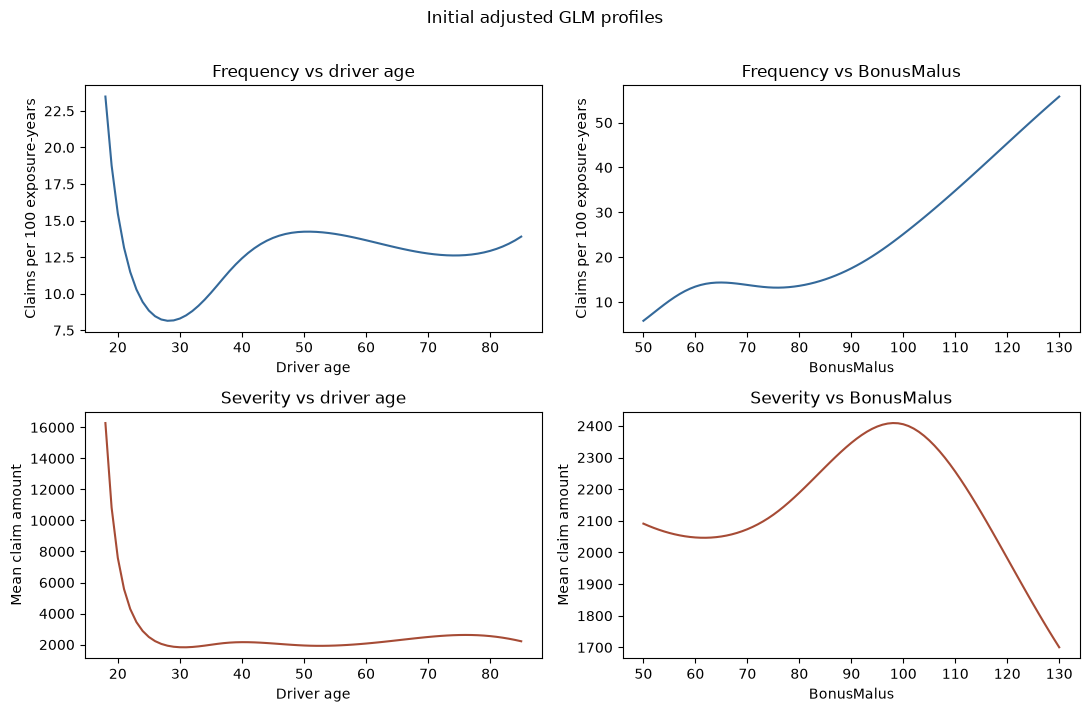

In [7]:
reference_profile = {
    "DrivAge": 45,
    "BonusMalus": 70,
    "VehAge": 6,
    "VehPower": 6,
    "VehGas": "Diesel",
    "Density": float(train_frequency["Density"].median()),
    "Region": train_frequency["Region"].mode().iat[0],
}
print("Reference profile:", reference_profile)

def prediction_grid(variable, values):
    grid = pd.DataFrame([reference_profile] * len(values))
    grid[variable] = values
    return grid

age_grid = prediction_grid("DrivAge", np.arange(18, 86))
bonus_grid = prediction_grid("BonusMalus", np.arange(50, 131))

fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for column, (variable, grid, xlabel) in enumerate([
    ("DrivAge", age_grid, "Driver age"),
    ("BonusMalus", bonus_grid, "BonusMalus"),
]):
    frequency_rate = frequency_fit.predict(
        grid, exposure=np.ones(len(grid))
    ) * 100
    severity_mean = severity_fit.predict(grid)
    axes[0, column].plot(grid[variable], frequency_rate, color="#34699a")
    axes[0, column].set(xlabel=xlabel,
                        ylabel="Claims per 100 exposure-years")
    axes[1, column].plot(grid[variable], severity_mean, color="#a64b35")
    axes[1, column].set(xlabel=xlabel,
                        ylabel="Mean claim amount")

axes[0, 0].set_title("Frequency vs driver age")
axes[0, 1].set_title("Frequency vs BonusMalus")
axes[1, 0].set_title("Severity vs driver age")
axes[1, 1].set_title("Severity vs BonusMalus")
fig.suptitle("Initial adjusted GLM profiles", y=1.01)
plt.tight_layout()
plt.show()

## First-specification observations

These are **first-specification GLMs**, not selected final models. The frequency model is a Poisson GLM with a log link and policy exposure; the severity model is a Gamma GLM with a log link for positive claim amounts. Both include flexible spline effects for driver age and BonusMalus alongside the specified vehicle and geographic predictors. Policies have been split into training and test sets, but the test data have deliberately not been used to assess either fit.

The frequency model gives interpretable adjusted associations that broadly align with the descriptive EDA. Holding its other predictors fixed, Regular fuel has an estimated frequency ratio of **0.835** relative to Diesel, each unit of vehicle power has a ratio of **1.026**, and doubling density has a ratio of **1.054**. The age and BonusMalus splines allow nonlinear shapes without imposing the EDA bands as model cutoffs or forcing a single linear effect. These comparisons are conditional associations, not causal effects.

The frequency model's Pearson chi-square divided by residual degrees of freedom is about **1.87**. Counts therefore vary appreciably more than a literal Poisson variance assumption would predict. This raises questions about uncertainty estimates and the full count distribution; it does not, by itself, invalidate the fitted conditional mean. Later work can examine robust or overdispersion-adjusted inference and alternatives such as a Negative Binomial model, without selecting among them here.

The Gamma log-link model is a conventional starting point for positive severity, but its Pearson scale is about **18.1**. Together with the extreme right tail documented in Notebook 03, this indicates highly variable claim amounts and raises questions about the adequacy and stability of the fitted conditional model. This is not the same diagnosis as Poisson overdispersion: the Gamma family already estimates a dispersion parameter, and this result alone does not establish that another distribution is preferable.

Adjusted severity ratios are nearly neutral for Regular versus Diesel fuel (**1.003**) and for a doubling of density (**1.005**), although both characteristics show clearer frequency associations. Vehicle power has an estimated severity ratio of **1.040** per unit. The spline profiles, especially the steep predicted severity at the youngest ages, remain provisional: the earlier EDA showed that a few extreme claims can strongly influence subgroup means.

A poor fit for a complete conditional distribution does not automatically imply poor estimation of its **conditional mean**. Expected frequency and expected severity are the quantities ultimately needed for pure premium. Yet mean severity is intrinsically sensitive to rare, very large claims that dominate total losses. The reserved test data were later used in Notebook 07 to assess generalization after model development was complete; Notebook 04 itself did not use them to resolve these diagnostics or choose a model.

## Development cross-validation: policy-level folds

The reserved 20% test set remains sealed for final evaluation. Within the 80% training sample, five reproducible folds are assigned **at the policy level**. Every claim from a policy inherits the same fold; a policy and its claims cannot appear on opposite sides of a development validation split. Folds are randomized without balancing catastrophic claims, so their natural concentration remains visible. No candidate model is compared in this section.

In [8]:
fold_rng = np.random.default_rng(2027)
shuffled_positions = fold_rng.permutation(len(train_frequency))
fold_number = np.empty(len(train_frequency), dtype=int)
for fold_id, positions in enumerate(np.array_split(shuffled_positions, 5)):
    fold_number[positions] = fold_id + 1

train_frequency["cv_fold"] = fold_number
fold_by_policy = train_frequency.set_index("IDpol")["cv_fold"]
train_claims["cv_fold"] = train_claims["IDpol"].map(fold_by_policy)

assert train_claims["cv_fold"].notna().all()
assert train_frequency.groupby("IDpol")["cv_fold"].nunique().eq(1).all()
assert train_claims.groupby("IDpol")["cv_fold"].nunique().eq(1).all()

policy_fold_summary = train_frequency.groupby("cv_fold").agg(
    policies=("IDpol", "size"),
    exposure_years=("Exposure", "sum"),
    reported_claims=("ClaimNb", "sum"),
)
claim_fold_summary = train_claims.groupby("cv_fold").agg(
    claim_rows=("IDpol", "size"),
    total_claim_amount=("ClaimAmount", "sum"),
    mean_claim_amount=("ClaimAmount", "mean"),
    largest_claim=("ClaimAmount", "max"),
)
fold_summary = policy_fold_summary.join(claim_fold_summary)
assert fold_summary["reported_claims"].eq(fold_summary["claim_rows"]).all()
display(fold_summary.round(2))

,policies,exposure_years,reported_claims,claim_rows,total_claim_amount,mean_claim_amount,largest_claim
cv_fold,,,,,,,
1,108566,57553.70,4184,4184,11090200.65,2650.62,1403057.40
2,108566,57431.08,4275,4275,12424027.67,2906.21,4075400.56
3,108566,57304.54,4165,4165,8495496.07,2039.73,205432.05
4,108566,57478.83,4288,4288,8599501.23,2005.48,369131.88
5,108566,57335.51,4167,4167,7565921.59,1815.68,209695.87


Each fold is a development validation set once, with the other four folds used for fitting. The resulting out-of-fold predictions were later compared across the five folds, while the final test set remained outside model fitting and selection. Differences in fold-level claim amounts are part of the severity stability question, not a reason to redistribute large claims among folds.

## Baseline five-fold cross-validation

The current Poisson and Gamma specifications are refitted on four development folds and used to predict the fifth. Each training policy and each training claim receives exactly one **out-of-fold (OOF)** prediction. No new candidate model is introduced, and the final 20% test set remains outside every fit and metric below.

Metrics are set before viewing the CV results. For frequency: observed and predicted claim totals, observed/predicted (O/P), and mean Poisson deviance for policy counts. For severity: observed and predicted mean claim amount, aggregate O/P, mean absolute error (MAE), and root mean squared error (RMSE). Fold results remain separate so catastrophic-claim variation is visible; RMSE is not used alone to judge the severity model.

### Poisson frequency: out-of-fold predictions

In [9]:
from scipy.special import xlogy

frequency_oof = train_frequency[["IDpol", "cv_fold", "Exposure", "ClaimNb"]].copy()
frequency_oof["predicted_claims"] = np.nan
frequency_fold_results = []

for fold_id in range(1, 6):
    print(f"Fitting Poisson fold {fold_id}")
    fit_rows = train_frequency.loc[train_frequency["cv_fold"] != fold_id]
    validation_rows = train_frequency.loc[train_frequency["cv_fold"] == fold_id]

    fold_model = sm.GLM.from_formula(
        "ClaimNb ~ " + predictor_formula,
        data=fit_rows,
        family=sm.families.Poisson(),
        exposure=fit_rows["Exposure"],
    )
    fold_fit = fold_model.fit(maxiter=100)
    if not fold_fit.converged:
        raise RuntimeError(f"Poisson fit did not converge in fold {fold_id}")

    predicted = np.asarray(fold_fit.predict(
        validation_rows, exposure=validation_rows["Exposure"]
    ))
    observed = validation_rows["ClaimNb"].to_numpy()
    frequency_oof.loc[validation_rows.index, "predicted_claims"] = predicted

    poisson_deviance = 2 * (xlogy(observed, observed / predicted)
                            - (observed - predicted))
    frequency_fold_results.append({
        "fold": fold_id,
        "policies": len(validation_rows),
        "exposure_years": validation_rows["Exposure"].sum(),
        "observed_claims": observed.sum(),
        "predicted_claims": predicted.sum(),
        "observed_to_predicted": observed.sum() / predicted.sum(),
        "mean_poisson_deviance": poisson_deviance.mean(),
    })

frequency_fold_summary = pd.DataFrame(frequency_fold_results).set_index("fold")
display(frequency_fold_summary.round(4))

Fitting Poisson fold 1


Fitting Poisson fold 2


Fitting Poisson fold 3


Fitting Poisson fold 4


Fitting Poisson fold 5


,policies,exposure_years,observed_claims,predicted_claims,observed_to_predicted,mean_poisson_deviance
fold,,,,,,
1,108566,57553.6994,4184,4238.7188,0.9871,0.2417
2,108566,57431.0807,4275,4213.5442,1.0146,0.2433
3,108566,57304.5448,4165,4195.4794,0.9927,0.2406
4,108566,57478.8344,4288,4219.9491,1.0161,0.2411
5,108566,57335.5094,4167,4211.1427,0.9895,0.2394


### Gamma severity: out-of-fold predictions

In [10]:
severity_oof = train_claims[["IDpol", "cv_fold", "ClaimAmount"]].copy()
severity_oof.insert(0, "development_claim_row", np.arange(1, len(severity_oof) + 1))
severity_oof["predicted_mean_severity"] = np.nan
severity_fold_results = []

for fold_id in range(1, 6):
    print(f"Fitting Gamma fold {fold_id}")
    fit_rows = train_claims.loc[train_claims["cv_fold"] != fold_id]
    validation_rows = train_claims.loc[train_claims["cv_fold"] == fold_id]

    fold_model = sm.GLM.from_formula(
        "ClaimAmount ~ " + predictor_formula,
        data=fit_rows,
        family=sm.families.Gamma(link=sm.families.links.Log()),
    )
    # Initialize from the fitting claims only; BFGS avoids unstable IRLS steps.
    start_params = np.zeros(fold_model.exog.shape[1])
    start_params[fold_model.exog_names.index("Intercept")] = np.log(
        fit_rows["ClaimAmount"].mean()
    )
    fold_fit = fold_model.fit(start_params=start_params, method="bfgs", maxiter=1000)
    if not fold_fit.mle_retvals["converged"]:
        raise RuntimeError(f"Gamma fit did not converge in fold {fold_id}")

    predicted = np.asarray(fold_fit.predict(validation_rows))
    observed = validation_rows["ClaimAmount"].to_numpy()
    severity_oof.loc[validation_rows.index, "predicted_mean_severity"] = predicted

    severity_fold_results.append({
        "fold": fold_id,
        "claims": len(validation_rows),
        "observed_mean": observed.mean(),
        "predicted_mean": predicted.mean(),
        "observed_to_predicted": observed.sum() / predicted.sum(),
        "MAE": np.mean(np.abs(observed - predicted)),
        "RMSE": np.sqrt(np.mean((observed - predicted) ** 2)),
    })

severity_fold_summary = pd.DataFrame(severity_fold_results).set_index("fold")
display(severity_fold_summary.round(4))

Fitting Gamma fold 1


Fitting Gamma fold 2


Fitting Gamma fold 3


Fitting Gamma fold 4


Fitting Gamma fold 5


,claims,observed_mean,predicted_mean,observed_to_predicted,MAE,RMSE
fold,,,,,,
1,4184,2650.6216,2096.2785,1.2644,2572.6769,3.068406e+04
2,4275,2906.2053,2096.5749,1.3862,2799.9577,6.263038e+04
3,4165,2039.7350,2223.3676,0.9174,2034.9414,7.174479e+03
4,4288,2005.4807,2299.6710,0.8721,2123.3949,1.053132e+04
5,4167,1815.6759,502243.8803,0.0036,501820.4452,3.227165e+07


### Retain the row-level OOF predictions

The two CSVs below contain **development data only**. They preserve the observed response, fold assignment, and prediction for later calibration and stability analysis. The severity row number identifies distinct claims that share a policy ID; it is a position within this reproducible development extract, not a source claim identifier.

In [11]:
frequency_oof["predicted_annual_frequency"] = (
    frequency_oof["predicted_claims"] / frequency_oof["Exposure"]
)

assert frequency_oof["predicted_claims"].notna().all()
assert severity_oof["predicted_mean_severity"].notna().all()
assert np.isfinite(frequency_oof["predicted_claims"]).all()
assert np.isfinite(severity_oof["predicted_mean_severity"]).all()
assert frequency_oof["predicted_claims"].gt(0).all()
assert severity_oof["predicted_mean_severity"].gt(0).all()
assert frequency_oof["IDpol"].is_unique
assert severity_oof["development_claim_row"].is_unique
assert set(frequency_oof["IDpol"]).isdisjoint(set(test_frequency["IDpol"]))
assert set(severity_oof["IDpol"]).isdisjoint(set(test_frequency["IDpol"]))

processed_dir = Path("../data/processed")
processed_dir.mkdir(exist_ok=True)
frequency_oof_path = processed_dir / "04_poisson_frequency_oof.csv"
severity_oof_path = processed_dir / "04_gamma_severity_oof.csv"
frequency_oof.to_csv(frequency_oof_path, index=False)
severity_oof.to_csv(severity_oof_path, index=False)

print(f"Saved {len(frequency_oof):,} policy OOF rows to {frequency_oof_path}")
print(f"Saved {len(severity_oof):,} claim OOF rows to {severity_oof_path}")

Saved 542,830 policy OOF rows to ..\data\processed\04_poisson_frequency_oof.csv
Saved 21,079 claim OOF rows to ..\data\processed\04_gamma_severity_oof.csv


## Discussion and next steps

This notebook establishes initial actuarial GLM specifications and a development-stage diagnostic framework. The Poisson log-link frequency model incorporates policy exposure as an offset and provides a sensible first conditional-mean model. Pearson chi-square per residual degree of freedom is about 1.87, indicating moderate overdispersion relative to a literal Poisson count distribution. This does not by itself invalidate the fitted mean, but it motivates later comparison with Negative Binomial and more flexible approaches.

The Gamma log-link GLM is a conventional first model for positive claim severity and directly targets the arithmetic conditional mean, $E[Y\mid X]$. Severity showed much greater conditional variability and instability than frequency, consistent with the heavy and concentrated loss tail seen in the preceding EDA. The policy-level 80/20 development/test split and five policy-level development folds were established here. The reserved 20% test sample was not used to resolve fitting problems or choose a model.

The first severity spline specification revealed a specific extrapolation problem. For a validation claim of \$1,128.12 on a policy with `BonusMalus = 228`, the fitted model predicted about \$2.083 billion: that fold's fitting claims reached only `BonusMalus = 190`, and the spline contributed about +13.83 to the log-mean predictor. The log link amplified this out-of-support spline behavior; the observed claim was not extraordinary. Other high predicted severities for 18-year-old drivers arose within the age range represented in fitting data and raise a separate question about the stability of conditional severity relationships under extreme losses.

These diagnostics made Notebook 04 useful as an exploratory modeling step rather than a definitive model-selection stage. Notebook 05 compared safer conventional predictor forms and tree boosting, Poisson and Negative Binomial frequency models, and multiple severity approaches using systematic out-of-fold calibration and stability checks. Notebook 06 then examined an explicit body/tail severity approach, but retained Gamma as the comparatively stable conditional-mean benchmark. Notebook 07 refit the frozen Boosted Poisson frequency and Gamma severity specifications on all development data and evaluated them once on the reserved test sample. The test sample was not used to resolve the Notebook 04 fitting problems or to select the later models.